<a href="https://colab.research.google.com/github/santhiago-svb/Statistical-Learning-e22047/blob/main/Assignment7_Kalman_filter_assignment.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Q. Analytical Derivation

# Kalman Filter Derivations

### Fundamental Properties of Gaussian Variables
For these derivations, we heavily rely on two properties of multivariate Gaussian distributions:
1. **Linear Transformation:** If $X \sim \mathscr{N}(\mu, \Sigma)$, then $AX + b \sim \mathscr{N}(A\mu + b, A\Sigma A^T)$.
2. **Sum of Independent Gaussians:** If $X \sim \mathscr{N}(\mu_X, \Sigma_X)$ and $Y \sim \mathscr{N}(\mu_Y, \Sigma_Y)$ are independent, then $X + Y \sim \mathscr{N}(\mu_X + \mu_Y, \Sigma_X + \Sigma_Y)$.

---

### 1. Prior State Estimation ($x_k^-$)

The state-space prediction equation is:
$$x^{-}_k = A_{k-1}\,x^{+}_{k-1} + G_{k-1}\,w_{k-1}$$

Since $x^{+}_{k-1} \sim \mathscr{N}(m_{k-1}, P_{k-1})$ and $w_{k-1} \sim \mathscr{N}(0, \Sigma_p)$ are independent Gaussian vectors, $x^{-}_k$ is a linear combination of independent Gaussians and is also Gaussian.

#### Mean ($m_k^-$):
$$\mathbb{E}[x_k^-] = \mathbb{E}[A_{k-1}x^{+}_{k-1} + G_{k-1}w_{k-1}]$$
$$m_k^- = A_{k-1}\mathbb{E}[x^{+}_{k-1}] + G_{k-1}\mathbb{E}[w_{k-1}]$$
$$m_k^- = A_{k-1}m_{k-1} + G_{k-1}(0) = A_{k-1}m_{k-1}$$

#### Covariance ($P_k^-$):
$$P_k^- = \text{Var}(x_k^-) = \text{Var}(A_{k-1}x^{+}_{k-1} + G_{k-1}w_{k-1})$$
Since $x^{+}_{k-1}$ and $w_{k-1}$ are independent, their cross-covariance is zero:
$$P_k^- = \text{Var}(A_{k-1}x^{+}_{k-1}) + \text{Var}(G_{k-1}w_{k-1})$$
$$P_k^- = A_{k-1}\text{Var}(x^{+}_{k-1})A_{k-1}^T + G_{k-1}\text{Var}(w_{k-1})G_{k-1}^T$$
$$P_k^- = A_{k-1}P_{k-1}A_{k-1}^T + G_{k-1}\Sigma_p G_{k-1}^T$$

$$\therefore x_k^- \sim \mathscr{N}(m_k^-, P_k^-)$$

---

### 2. Predicted Measurement Distribution ($y_k^-$)

The measurement model is given by:
$$y^{-}_k = H_k\,x^{-}_k + z_k$$
where $z_k \sim \mathscr{N}(0, \Sigma_m)$ is independent of $x^{-}_k$.

#### Mean:
$$\mathbb{E}[y_k^-] = \mathbb{E}[H_k x_k^- + z_k] = H_k \mathbb{E}[x_k^-] + \mathbb{E}[z_k] = H_k m_k^-$$

#### Covariance:
$$\text{Var}(y_k^-) = \text{Var}(H_k x_k^- + z_k) = \text{Var}(H_k x_k^-) + \text{Var}(z_k)$$
$$\text{Var}(y_k^-) = H_k \text{Var}(x_k^-) H_k^T + \Sigma_m = H_k P_k^- H_k^T + \Sigma_m$$

$$\therefore y_k^- \sim \mathscr{N}(H_k m_k^-, H_k P_k^- H_k^T + \Sigma_m)$$

---

### 3. Joint Distribution of $x_k^-$ and $y_k^-$

The joint vector is linear in its underlying Gaussian elements, making it jointly Gaussian:
$$\begin{bmatrix} x_k^- \\ y^{-}_k \end{bmatrix} \sim \mathscr{N}\left( \mu_{\text{joint}}, \Sigma_{\text{joint}} \right)$$

#### Joint Mean:
$$\mu_{\text{joint}} = \begin{bmatrix} \mathbb{E}[x_k^-] \\ \mathbb{E}[y_k^-] \end{bmatrix} = \begin{bmatrix} m_k^- \\ H_k m_k^- \end{bmatrix}$$

#### Joint Covariance:
$$\Sigma_{\text{joint}} = \begin{bmatrix} \text{Var}(x_k^-) & \text{Cov}(x_k^-, y_k^-) \\ \text{Cov}(y_k^-, x_k^-) & \text{Var}(y_k^-) \end{bmatrix}$$

We compute the cross-covariance term $\text{Cov}(x_k^-, y_k^-)$:
$$\text{Cov}(x_k^-, y_k^-) = \mathbb{E}\left[ (x_k^- - m_k^-)(y_k^- - H_k m_k^-)^T \right]$$
Substitute $y_k^- - H_k m_k^- = H_k(x_k^- - m_k^-) + z_k$:
$$\text{Cov}(x_k^-, y_k^-) = \mathbb{E}\left[ (x_k^- - m_k^-)(H_k(x_k^- - m_k^-) + z_k)^T \right]$$
$$\text{Cov}(x_k^-, y_k^-) = \mathbb{E}\left[ (x_k^- - m_k^-)(x_k^- - m_k^-)^T \right] H_k^T + \mathbb{E}\left[ (x_k^- - m_k^-) z_k^T \right]$$
Since $x_k^-$ and $z_k$ are independent, the second term vanishes:
$$\text{Cov}(x_k^-, y_k^-) = P_k^- H_k^T$$
By symmetry, $\text{Cov}(y_k^-, x_k^-) = \left(P_k^- H_k^T\right)^T = H_k P_k^-$.

$$\therefore \begin{bmatrix} x_k^- \\ y^{-}_k \end{bmatrix} \sim \mathscr{N}\left(
\begin{bmatrix} m_k^- \\ H_k m_k^- \end{bmatrix},
\begin{bmatrix} P_k^- & P_k^- H_k^T \\ H_k P_k^- & H_k P_k^- H_k^T + \Sigma_m \end{bmatrix}
\right)$$

---

### 4 & 5. Posterior State Distribution ($x^{+}_k$) via Conditional Gaussians

Given a joint Gaussian distribution:
$$\begin{bmatrix} X \\ Y \end{bmatrix} \sim \mathscr{N}\left( \begin{bmatrix} \mu_X \\ \mu_Y \end{bmatrix}, \begin{bmatrix} \Sigma_{XX} & \Sigma_{XY} \\ \Sigma_{YX} & \Sigma_{YY} \end{bmatrix} \right)$$
The conditional distribution $(X \mid Y = y^{\mathrm{obs}})$ is Gaussian with:
$$\mathbb{E}[X \mid Y = y^{\mathrm{obs}}] = \mu_X + \Sigma_{XY} \Sigma_{YY}^{-1} (y^{\mathrm{obs}} - \mu_Y)$$
$$\text{Var}(X \mid Y = y^{\mathrm{obs}}) = \Sigma_{XX} - \Sigma_{XY} \Sigma_{YY}^{-1} \Sigma_{YX}$$

Mapping this property directly to our joint system where $X = x_k^-$ and $Y = y_k^-$:

#### Answer to Question 5:

# Q. 1-D Example

from IPython.display import display, Markdown

# ==============================================================================
# LATEX DERIVATIONS FOR QUESTIONS 1 - 4
# ==============================================================================

latex_content = r"""
# Scalar Kalman Filter Derivations

### 1. State Prediction Step ($m_k^-$, $P_k^-$)
Given the scalar state equation:
$$x^-_k = a\,x^+_{k-1} + w_{k-1}$$
where $x^+_{k-1} \sim \mathscr{N}(m_{k-1}, P_{k-1})$ and $w_{k-1} \sim \mathscr{N}(0,q)$ are independent.

* **Prior Mean ($m_k^-$):**
  $$m_k^- = \mathbb{E}[x^-_k] = \mathbb{E}[a\,x^+_{k-1} + w_{k-1}] = a\,\mathbb{E}[x^+_{k-1}] + \mathbb{E}[w_{k-1}]$$
  $$m_k^- = a\,m_{k-1} + 0 = a\,m_{k-1}$$

* **Prior Variance ($P_k^-$):**
  $$P_k^- = \text{Var}(x^-_k) = \text{Var}(a\,x^+_{k-1} + w_{k-1})$$
  Since $x^+_{k-1}$ and $w_{k-1}$ are independent:
  $$P_k^- = a^2\text{Var}(x^+_{k-1}) + \text{Var}(w_{k-1}) = a^2 P_{k-1} + q$$

---

### 2. Measurement Update Step ($m_k$, $P_k$)
From the joint Gaussian properties of the state and measurement updates, the innovation covariance is $S_k = h^2 P_k^- + r$ and the Kalman gain is $K_k = \frac{P_k^- h}{S_k}$.

* **Posterior Mean ($m_k$):**
  $$m_k = m_k^- + K_k v_k = m_k^- + K_k(y^{\mathrm{obs}}_k - h\,m_k^-)$$
  Substituting $K_k$:
  $$m_k = m_k^- + \frac{P_k^- h}{S_k}\bigl(y^{\mathrm{obs}}_k - h\,m_k^-\bigr)$$

* **Posterior Variance ($P_k$):**
  $$P_k = (1 - K_k h)P_k^-$$
  Substituting $K_k$:
  $$P_k = \Bigl(1 - \frac{P_k^- h^2}{S_k}\Bigr) P_k^-$$

---

### 3. Predictive Measurement Distribution
We seek $p(y^-_k \mid Y_{k-1})$. Given $y^-_k = h\,x^-_k + z_k$, where $x^-_k \mid Y_{k-1} \sim \mathscr{N}(m_k^-, P_k^-)$ and $z_k \sim \mathscr{N}(0,r)$.

* **Mean:**
  $$\mathbb{E}[y^-_k \mid Y_{k-1}] = \mathbb{E}[h\,x^-_k + z_k \mid Y_{k-1}] = h m_k^- + 0 = h m_k^-$$
* **Variance:**
  $$\text{Var}(y^-_k \mid Y_{k-1}) = \text{Var}(h\,x^-_k + z_k \mid Y_{k-1}) = h^2 P_k^- + r$$

$$\therefore p(y^-_k \mid Y_{k-1}) = \mathscr{N}\bigl(h\,m_k^-,\; h^2 P_k^- + r\bigr)$$

---

### 4. Posterior-Predictive Measurement Distribution
We seek $p(y^-_k \mid Y_k)$, which describes a subsequent hypothetical measurement at step $k$ after having already updated the state to $x^+_k \mid Y_k \sim \mathscr{N}(m_k, P_k)$.

* **Mean:**
  $$\mathbb{E}[y^-_k \mid Y_k] = \mathbb{E}[h\,x^+_k + z_k \mid Y_k] = h m_k$$
* **Variance:**
  $$\text{Var}(y^-_k \mid Y_k) = \text{Var}(h\,x^+_k + z_k \mid Y_k) = h^2 P_k + r$$

$$\therefore p(y^-_k \mid Y_k) = \mathscr{N}\bigl(h\,m_k,\; h^2 P_k + r\bigr)$$
"""

display(Markdown(latex_content))

# Q. 2D-Position Estimation

## Part A

## Derivation of the State-Space Matrices

### 1. State Transition Matrix ($A$)
Assuming a constant velocity model over a time step $\Delta t$, the kinematic equations are:
$$p_x(k) = p_x(k-1) + v_x(k-1)\Delta t$$
$$p_y(k) = p_y(k-1) + v_y(k-1)\Delta t$$
$$v_x(k) = v_x(k-1)$$
$$v_y(k) = v_y(k-1)$$

In matrix form, $x_k = A x_{k-1}$:
$$
\begin{bmatrix}
p_x(k)\\
p_y(k)\\
v_x(k)\\
v_y(k)
\end{bmatrix}
=
\begin{bmatrix}
1 & 0 & \Delta t & 0\\
0 & 1 & 0 & \Delta t\\
0 & 0 & 1 & 0\\
0 & 0 & 0 & 1
\end{bmatrix}
\begin{bmatrix}
p_x(k-1)\\
p_y(k-1)\\
v_x(k-1)\\
v_y(k-1)
\end{bmatrix}
$$
$$\therefore A = \begin{bmatrix} 1 & 0 & \Delta t & 0\\ 0 & 1 & 0 & \Delta t\\ 0 & 0 & 1 & 0\\ 0 & 0 & 0 & 1 \end{bmatrix}$$

---

### 2. Measurement Matrix ($H$)
The measurement vector directly extracts the positions from the state vector without measuring the velocities:
$$p_x^{\mathrm{meas}}(k) = p_x(k)$$
$$p_y^{\mathrm{meas}}(k) = p_y(k)$$

In matrix form, $y_k = H x_k$:
$$
\begin{bmatrix}
p_x^{\mathrm{meas}}(k)\\
p_y^{\mathrm{meas}}(k)
\end{bmatrix}
=
\begin{bmatrix}
1 & 0 & 0 & 0\\
0 & 1 & 0 & 0
\end{bmatrix}
\begin{bmatrix}
p_x(k)\\
p_y(k)\\
v_x(k)\\
v_y(k)
\end{bmatrix}
$$
$$\therefore H = \begin{bmatrix} 1 & 0 & 0 & 0\\ 0 & 1 & 0 & 0 \end{bmatrix}$$

---

### 3. Process Noise Coupling Matrix ($G$)
If the process noise vector $w_{k-1} = [a_x, a_y]^T$ represents unmodeled random accelerations, their integrated effect on position and velocity over $\Delta t$ follows Newtonian physics:
$$\Delta p = \frac{1}{2}\Delta t^2 a \quad \text{and} \quad \Delta v = \Delta t a$$

Mapping these perturbations to the state vector via $G w_{k-1}$:
$$
\begin{bmatrix}
\frac{1}{2}\Delta t^2 a_x \\
\frac{1}{2}\Delta t^2 a_y \\
\Delta t a_x \\
\Delta t a_y
\end{bmatrix}
=
\begin{bmatrix}
\frac{1}{2}\Delta t^2 & 0\\
0 & \frac{1}{2}\Delta t^2\\
\Delta t & 0\\
0 & \Delta t
\end{bmatrix}
\begin{bmatrix}
a_x\\
a_y
\end{bmatrix}
$$
$$\therefore G = \begin{bmatrix} \frac{1}{2}\Delta t^2 & 0\\ 0 & \frac{1}{2}\Delta t^2\\ \Delta t & 0\\ 0 & \Delta t \end{bmatrix}$$

## Part B

Develop a python based method to filter a sequence of noisy GPS obtained position meaurements.

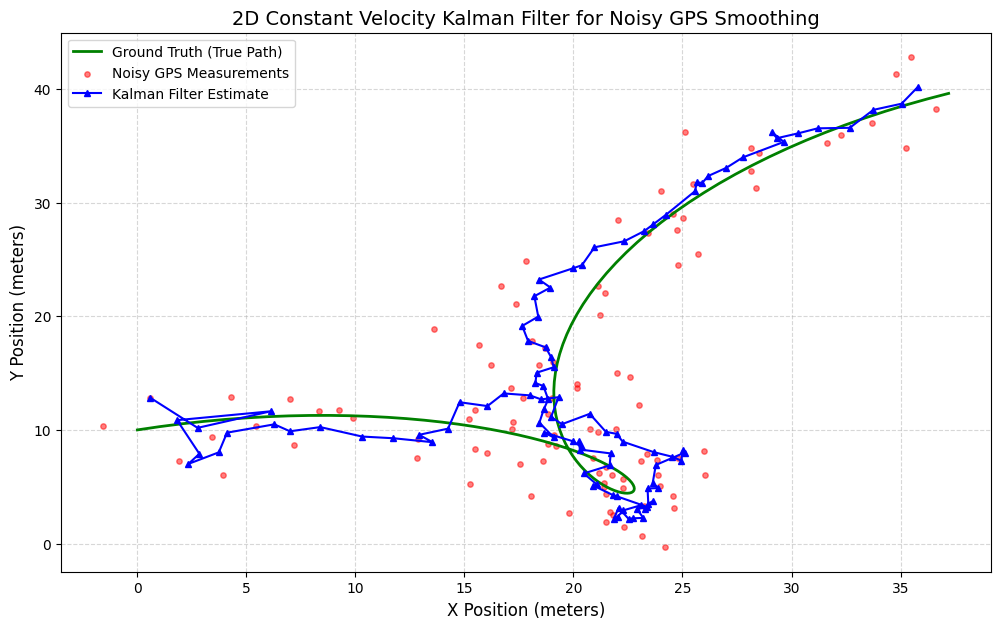

In [4]:
import numpy as np
import matplotlib.pyplot as plt

class GPSKalmanFilter2D:
    def __init__(self, dt, process_noise_std=0.1, measurement_noise_std=2.0):
        """
        Initializes a 2D Constant-Velocity Kalman Filter.

        State vector x: [pos_x, pos_y, vel_x, vel_y]^T
        Measurement vector y: [pos_x_meas, pos_y_meas]^T
        """
        self.dt = dt

        # State Transition Matrix (A)
        self.A = np.array([
            [1, 0, dt,  0],
            [0, 1,  0, dt],
            [0, 0,  1,  0],
            [0, 0,  0,  1]
        ])

        # Noise Coupling Matrix (G)
        self.G = np.array([
            [0.5 * dt**2, 0],
            [0, 0.5 * dt**2],
            [dt, 0],
            [0, dt]
        ])

        # Measurement Matrix (H)
        self.H = np.array([
            [1, 0, 0, 0],
            [0, 1, 0, 0]
        ])

        # Process Noise Covariance (Q = G * Sigma_p * G^T)
        sigma_p = process_noise_std**2
        self.Q = self.G @ (np.eye(2) * sigma_p) @ self.G.T

        # Measurement Noise Covariance (R)
        self.R = np.eye(2) * (measurement_noise_std**2)

        # Initial State Estimate (x) and Covariance (P)
        self.x = np.zeros((4, 1))
        self.P = np.eye(4) * 10.0  # High initial uncertainty

        self.initialized = False

    def initialize(self, init_x, init_y):
        """Initializes the filter with the first GPS measurement."""
        self.x = np.array([[init_x], [init_y], [0.0], [0.0]])
        self.P = np.eye(4) * 10.0
        self.initialized = True

    def predict(self):
        """Predicts the next state and covariance (Time Update)."""
        self.x = self.A @ self.x
        self.P = self.A @ self.P @ self.A.T + self.Q
        return self.x

    def update(self, z):
        """Updates the state with a new measurement (Measurement Update)."""
        # Innovation/Residual
        v = z - (self.H @ self.x)

        # Innovation Covariance
        S = self.H @ self.P @ self.H.T + self.R

        # Kalman Gain
        K = self.P @ self.H.T @ np.linalg.inv(S)

        # State and Covariance Correction
        self.x = self.x + K @ v
        self.P = (np.eye(4) - K @ self.H) @ self.P
        return self.x

    def filter_sequence(self, measurements):
        """
        Filters an entire array of noisy measurements.
        measurements: shape (N, 2) array of [x, y] coordinates
        """
        estimated_states = []

        for z_raw in measurements:
            z = z_raw.reshape(2, 1)

            if not self.initialized:
                self.initialize(z[0, 0], z[1, 0])
                estimated_states.append(self.x.copy())
                continue

            self.predict()
            self.update(z)
            estimated_states.append(self.x.copy())

        return np.array(estimated_states).squeeze()

# ==========================================
# Example Simulation & Testing
# ==========================================
if __name__ == "__main__":
    # Parameters
    N = 100         # Number of timesteps
    dt = 1.0        # Time step (e.g., 1 second interval GPS updates)
    r_std = 2.5     # Simulated GPS noise (meters) standard deviation
    q_std = 0.1     # System acceleration standard deviation

    # 1. Generate an ideal ground truth trajectory (e.g., circular path)
    t = np.linspace(0, 20, N)
    true_x = 10 * np.sin(0.3 * t) + 2 * t
    true_y = 10 * np.cos(0.3 * t) + 1.5 * t

    # 2. Add Gaussian noise to simulate realistic GPS degradation
    noise_x = np.random.normal(0, r_std, N)
    noise_y = np.random.normal(0, r_std, N)
    noisy_measurements = np.column_stack((true_x + noise_x, true_y + noise_y))

    # 3. Apply the Kalman Filter
    kf = GPSKalmanFilter2D(dt=dt, process_noise_std=q_std, measurement_noise_std=r_std)
    filtered_results = kf.filter_sequence(noisy_measurements)

    # Extract positions
    filtered_x = filtered_results[:, 0]
    filtered_y = filtered_results[:, 1]

    # 4. Plotting results
    plt.figure(figsize=(12, 7))
    plt.plot(true_x, true_y, 'g-', lw=2, label='Ground Truth (True Path)')
    plt.scatter(noisy_measurements[:, 0], noisy_measurements[:, 1], color='red', alpha=0.5, s=15, label='Noisy GPS Measurements')
    plt.plot(filtered_x, filtered_y, 'b-^', lw=1.5, markersize=4, label='Kalman Filter Estimate')

    plt.title('2D Constant Velocity Kalman Filter for Noisy GPS Smoothing', fontsize=14)
    plt.xlabel('X Position (meters)', fontsize=12)
    plt.ylabel('Y Position (meters)', fontsize=12)
    plt.legend(loc='best')
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.show()